# Perfect Foresight CRRA Model - Approximation and Savings Rate
## by Nathan Robino


In [ ]:
# Initial notebook set up
from HARK.ConsumptionSaving.ConsIndShockModel import (
    PerfForesightConsumerType,
    init_perfect_foresight,
)  # Import the consumer type
import matplotlib.pyplot as plt

import numpy as np
from copy import deepcopy
def mystr(number):
    return "{:.4f}".format(number)

# These last two will make our charts look nice
plt.style.use("seaborn-v0_8-darkgrid")
palette = plt.get_cmap("Dark2")

In [ ]:
# Set up a HARK Perfect Foresight Consumer called PFagent
Paramod    = deepcopy(init_perfect_foresight)

# Extract the parameters from the dictionary to make them easy to reference
CRRA       = Paramod["CRRA"]       = 2 # Coefficient of relative risk aversion
Rfree      = Paramod["Rfree"][0]   = 1.03 # Interest factor on assets
DiscFac    = Paramod["DiscFac"]    = 0.96 # Intertemporal discount factor
PermGroFac = Paramod["PermGroFac"] = [1.01] # Permanent income growth factor
LivPrb     = Paramod["LivPrb"]     = [1.0]  # Survival probability of 100 percent
cycles     = Paramod["cycles"]     = 0 # This says that it is an infinite horizon model

# Check the conditions
print(round(PermGroFac[0]/Rfree,3)) # human wealth condition
print(round(((Rfree*DiscFac)**(1/-CRRA))/Rfree,3)) # impatience condition

0.981
0.976


In [ ]:
# Now let's pass our dictionary to our consumer class to create an instance
PFagent = PerfForesightConsumerType(
    **Paramod
)  # Any parameters we did not modify get their default values

In [ ]:
# Set out some range of market resources that we want to plot consumption for
mMin = 0; mMax = 10; numPoints = 100
m_range = np.linspace(mMin, mMax, numPoints)

# Create array of Rfree values, and calculate the patience factor
howManyR = 11; Rfree_min = 1.01; Rfree_max = 1.20
Rfree_array = np.linspace(Rfree_min, Rfree_max, howManyR)

howManyD = 11; Disc_min = 0.8; Disc_max = 0.99
Disc_array = np.linspace(Disc_min, Disc_max, howManyD)

In [ ]:
# Plot average deviation from true consumption function
PFagent = PerfForesightConsumerType(
    **Paramod
)  # construct a consumer with our previous parameters

mean_dev     = np.zeros([howManyR,howManyD])
Pat_array    = np.zeros([howManyR,howManyD])
for d in range(howManyD):
    PFagent.DiscFac   = Disc_array[d]
    Pat_array[:,d]    = ((Rfree_array * PFagent.DiscFac) ** (1 / CRRA))
    for i in range(howManyR):
        PFagent.Rfree = [Rfree_array[i]]
        
        # Solve and approximate for each value of patience factor
        PFagent.solve()
        cHARK         = PFagent.solution[0].cFunc(m_range)
        wealthHmn     = PFagent.solution[0].hNrm
        wealthTot     = wealthHmn + m_range
        rfree         = Rfree - 1
        discRte       = (1 / DiscFac) - 1
        cApprox       = wealthTot * (rfree - (1 / CRRA) * (rfree - discRte))
        deviation     = np.mean(np.abs(cApprox / cHARK))
        mean_dev[i,d] = deviation

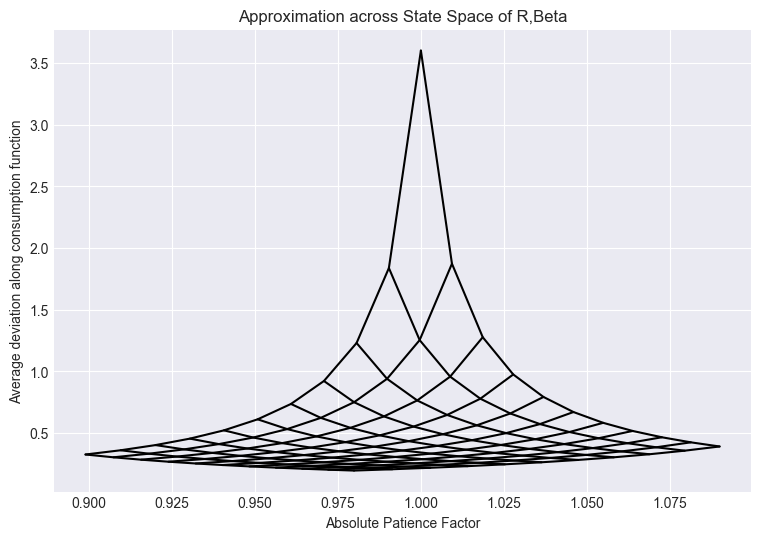

In [ ]:
# plot using matplotlib
plt.figure(figsize=(9, 6))
plt.plot(Pat_array, mean_dev, '-k')
plt.plot(Pat_array.T, mean_dev.T, '-k')
plt.xlabel("Absolute Patience Factor")
plt.ylabel("Average deviation along consumption function")
plt.title("Approximation across State Space of R,Beta")
plt.savefig("Figures/PS2Fig3.png")
plt.show()

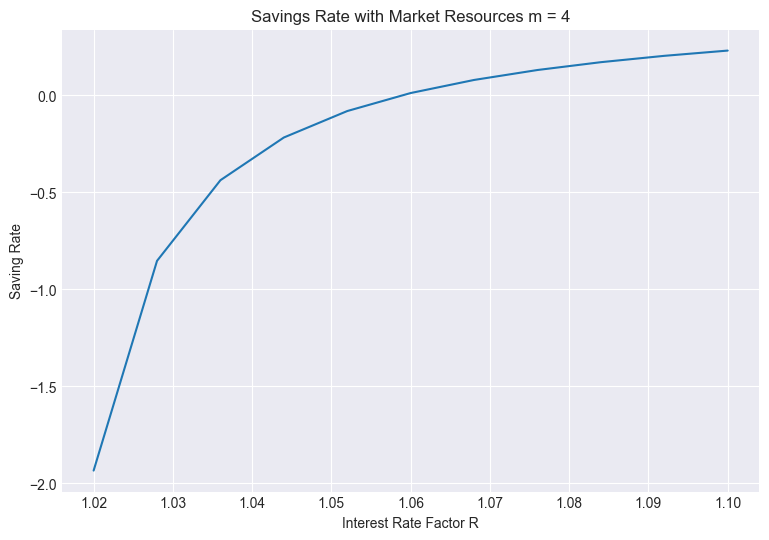

In [ ]:
# Now lets pass our dictionary to our consumer class
PFsavrate = PerfForesightConsumerType(**Paramod)

# Create grid for r
a_tm1 = 4
r_array = np.linspace(1.02,1.10,11)

# Compute income components at every a
cap_income_t = np.outer(a_tm1,(r_array - 1)) / PermGroFac
lab_income_t = 1

# and market resources
m_t = a_tm1 * Rfree / PermGroFac[0] + 1

c_t = np.zeros(11)
# Consumption
for i in range(len(r_array)):
    PFsavrate.Rfree = [r_array[i]]
    PFsavrate.solve()
    c_t[i] = PFsavrate.solution[0].cFunc(m_t)

# and finally the saving rate
ς_t = sav_rate_t = (cap_income_t + lab_income_t - c_t) / (cap_income_t + lab_income_t)

# And now the plot
plt.figure(figsize=(9, 6))
plt.plot(r_array,sav_rate_t.T)
plt.title("Savings Rate with Market Resources m = 4")
plt.xlabel("Interest Rate Factor R")
plt.ylabel("Saving Rate")
plt.savefig("Figures/PS2Fig4.png")
plt.show()

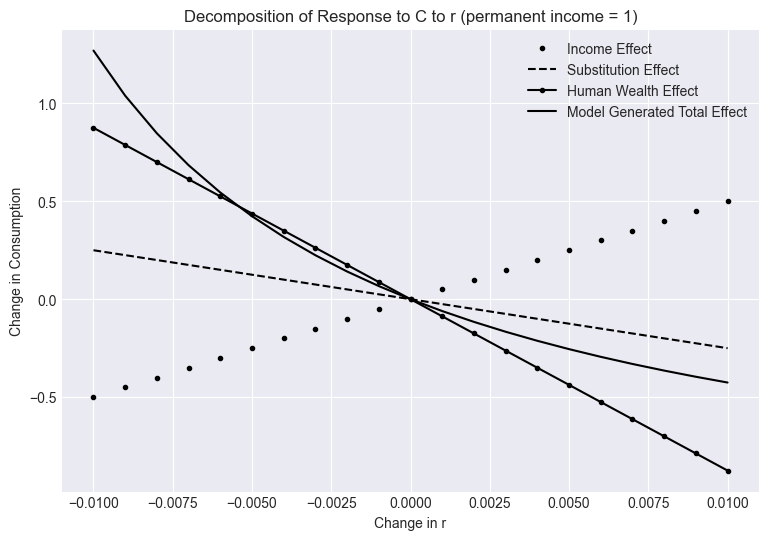

In [ ]:
# Now make figure about the size of the human wealth effect
r = Rfree - 1
g = PermGroFac[0] - 1
theta = 1 - DiscFac

# designate the channels in the approximation
IE = 1/(r-g)
SE = (-1/CRRA)*(1/(r-g))
HWE = -(r - (1/CRRA)*(r-theta))*(1/((r-g)**2))

# array of interest rate changes (and the resulting rates r)
dr_array = np.linspace(-0.01,0.01,21)
r_array = dr_array + Rfree

# solve the model for each of these r's
true_array = np.zeros(21)
# Consumption
for i in range(len(r_array)):
    PFsavrate.Rfree = [r_array[i]]
    PFsavrate.solve()
    true_array[i] = PFsavrate.solution[0].cFunc(0)

# compare to the linear approximation and channels
true_array = true_array - true_array[10]
IE_array = IE*dr_array
SE_array = SE*dr_array
HWE_array = HWE*dr_array

# And now the plot
plt.figure(figsize=(9, 6))
plt.plot(dr_array,IE_array, '.k', label="Income Effect")
plt.plot(dr_array,SE_array, '--k', label="Substitution Effect")
plt.plot(dr_array,HWE_array, '.-k', label="Human Wealth Effect")
plt.plot(dr_array,true_array, '-k', label="Model Generated Total Effect")
plt.title("Decomposition of Response to C to r (permanent income = 1)")
plt.xlabel("Change in r")
plt.ylabel("Change in Consumption")
plt.legend()
plt.savefig("Figures/PS2Fig5.png")
plt.show()